<a href="https://colab.research.google.com/github/DeiteEspinosa/Tecnicas-Estadisticas/blob/Notebook-1_Espacio-de-probabilidad/Espacios_de_probabilidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Espinosa Ponce Beatriz Deite

## $\color{lightcoral}{\text{Antecedentes}}$

El espacio muestral asociado a un experimento aleatorio

El espacio muestral $\Omega$ del experimento aleatorio de lanzar dos dados honestos, esta compuesto por todas las parejas ordenadas $(i,j)$ tales que $1\leq i,j \leq 6$

$$\Omega = \{ (i,j) \mid 1 \leq i,j \leq 6 \} $$
y sabemos que $\#\Omega = 6^2 = 36$

In [ ]:
#usamos itertools
from itertools import product

Omega = set(product([1,2,3,4,5,6], repeat = 2))
Omega

cardOmega = len(Omega)
cardOmega

"""
Se  𝑆𝑛
  el evento "La suma de los dados en  𝑛". Esto es:
𝑆𝑛={(𝑖,𝑗) ∈ Ω∣𝑖+𝑗=𝑛}
"""

def S(n):
    Sn = {(i,j) for i in range(1,7) for j in range(1,7) if i+j == n}
    return Sn

#Que la suma se 9
print("Que la suma se 9:", S(9))

#Que la suma se 12
print("Que la suma se 12", S(12))

Que la suma se 9: {(6, 3), (4, 5), (5, 4), (3, 6)}
Que la suma se 12 {(6, 6)}


In [ ]:
#La variable aleatoria asociadas a 𝑆𝑛

from fractions import Fraction
from collections import defaultdict

#Definir la función P((A))
#Es la probalilidad del evento A definida mediante la definición clásica

def P(A):
    P = Fraction(len(A), len(Omega))
    return P

#Vamos a definir un diccionario S
# (i,j) pares ordenados y los valores de su suma

S={(i,j) : i+j for i,j in Omega}

# Agrupación de combinaciónes por suma

dS = defaultdict(set)

# Vmaos a recorrer sobre los elementos en S y se van agrupar esos pares donde

for i,j in S.items():
    dS[j].add(i)

list(dS.items()) #Espacio muestral

""" LerS alamcena la probabilidad de cada posible suma:
- Usamos la función P(A) <- de densidad
   En otras palabras " la función de densidad" A es el conjunto de pares que producen la suma i """
LeyS = {i : P(A) for i, A in dS.items()} #Asigna la probalidad al esapcio muestral
LeyS

{7: Fraction(1, 6),
 4: Fraction(1, 12),
 9: Fraction(1, 9),
 10: Fraction(1, 12),
 6: Fraction(5, 36),
 8: Fraction(5, 36),
 11: Fraction(1, 18),
 3: Fraction(1, 18),
 5: Fraction(1, 9),
 2: Fraction(1, 36),
 12: Fraction(1, 36)}

Recordenis que uba variable aleatoiroa real $X$, es una función
$$ X : \Omega \to \mathbb{R} $$
y sabemos que función de densidad de la v.a. $X$, se define como sigue:
$$ f_X(x) = \begin{cases} \mathbb{P}(X=x), \quad \text{si } x\in R_{X} \\ \quad \text{e.o.c } \end{cases} $$
donde $R_X$ es el rango de la v.a $X$.

Para nuestro evento $S_n$, se tiene la siguiente variable aleatoria
$$S : \Omega \to \{2,3,4,5,6,7,8,9,10,11,12\}$$

In [ ]:
import pandas as pd #Importamos la libreria de Pandas
import numpy as np # Importar la libreria para calculos numericos

# Vamos a crear una serie
ley_S = pd.Series(LeyS)
ley_S.sort_index() #ordenar

# Creamos una función LeyS(i) devuelve la probabilidad de obtener la suma i, si está en el rango de psibles sumas

def leyS(i):
    if i in range(2,13):
        x = ley_S[i]
    else:
        x = 0 # si no está en el rango me devuelve 0
    return x

#  Vamos a crear el rango de S

#crear una lista con los posibles valores de la suma de los dados
rango_S = [k for k in range(2,13)]

#Obtenemos la probabilidad de cada suma
#p_k = [float(leyS(k)) for k in rango_S]
p_k = [float(leyS(k)) for k in range(2,13)]

# Creamos un DataFrame con:
# -los valores del rango_S
# -las probabilidades p_k
#Indexamos una etiqueta S_2,....,S_12

# zip() -> toma dos listas y las combina en pares ordenados
lS = pd.DataFrame(list(zip(rango_S, p_k)), index = [f"S_{i}" for i in range(2,13)], columns = ['rango','densidad'])
lS

,rango,densidad
S_2,2,0.027778
S_3,3,0.055556
S_4,4,0.083333
S_5,5,0.111111
S_6,6,0.138889
S_7,7,0.166667
S_8,8,0.138889
S_9,9,0.111111
S_10,10,0.083333
S_11,11,0.055556


<AxesSubplot: xlabel='rango'>

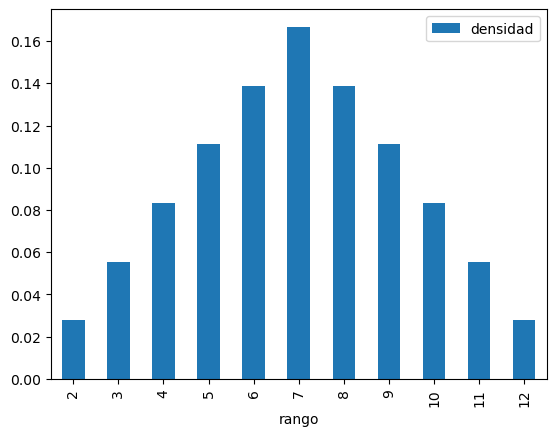

In [ ]:
lS.plot.bar(x = 'rango', y = 'densidad')

# Espacios de Probabilidad


# $\color{crimson}{\text{Probabilidad Clásica (Laplaciana)}}$

## $\color{lightcoral}{\text{Espacio muestral}}$
Para un experimento aleatorio, se tiene que $\Omega$ el espacio muestral.

Sea $A$ un evento, entonces

$$ \mathbb{P}(A) = \frac{\#A}{\#\Omega} $$

**EJEMPLO:** Sea el experimento de lanzar una moneda 3 veces, de manera independiente (es decir, el $i$-ésimo lanzamiento no me afecta al $i+1$ lanzamiento). El espacio muetral de este experimento es:

$$ \Omega = \{A,S\} \times \{A,S\} \times \{A,S\} = \{A,S\}^3 $$
y tenemos que $\#\Omega = 2^3$.

Sean los eventos:
* $A$: todos los resultados son águila
* $S$: todos los resultados son soles
* $E$: por lo menos un resultado es sol

Calcular las probabilidades de estos eventos:

**Solución** Vamos a descomponer mi conjunto $A$ de la siguiente manera:
$$A = A_1 \cap A_2 \cap A_3 $$
donde $A_i$: cae águila en el $i$-ésimo resultado.

In [ ]:
#Vamos a crear el espacio muestral
import itertools #importamos el módulo
from itertools import product

Omega = set(product({'A','S'},repeat=3))
Omega

{('A', 'A', 'A'),
 ('A', 'A', 'S'),
 ('A', 'S', 'A'),
 ('A', 'S', 'S'),
 ('S', 'A', 'A'),
 ('S', 'A', 'S'),
 ('S', 'S', 'A'),
 ('S', 'S', 'S')}

In [ ]:
car = len(Omega) #Cardinalidad de Omega
car

8

In [ ]:
# Vamos a crear el evento A_1
A_1 = {om for om in Omega if om[0] == 'A'} # la primera coordenada es águila
A_1

{('A', 'A', 'A'), ('A', 'A', 'S'), ('A', 'S', 'A'), ('A', 'S', 'S')}

In [ ]:
# Vamos a crear el evento A_2
A_2 = {om for om in Omega if om[1] == 'A'} # la segunda coordenada es águila
A_2

{('A', 'A', 'A'), ('A', 'A', 'S'), ('S', 'A', 'A'), ('S', 'A', 'S')}

In [ ]:
# Vamos a crear el evento A_3
A_3 = {om for om in Omega if om[2] == 'A'} # la tercera coordenada es águila
A_3

{('A', 'A', 'A'), ('A', 'S', 'A'), ('S', 'A', 'A'), ('S', 'S', 'A')}

In [ ]:
#Vamos a crear el evento A
A = A_1.intersection(A_2.intersection(A_3))
A

{('A', 'A', 'A')}

In [ ]:
len(A)

1

In [ ]:
# Vamos a calculamos la probailidad de A
P_A = len(A)/len(Omega)
P_A

0.125

Yo quiero expresar mi resultado en fracción, esto se hace de la siguiente manera:

In [ ]:
from fractions import Fraction

def p(E,Omega):
    p = Fraction(len(E),len(Omega))
    return p

In [ ]:
probA = p(A,Omega)
probA

Fraction(1, 8)

In [ ]:
# Vamos a crear el evento S_1
S_1 = {om for om in Omega if om[0] == 'S'} # la primera coordenada es sol
S_1

{('S', 'A', 'A'), ('S', 'A', 'S'), ('S', 'S', 'A'), ('S', 'S', 'S')}

In [ ]:
# Vamos a crear el evento S_2
S_2 = {om for om in Omega if om[1] == 'S'} # la segunda coordenada es sol
S_2

{('A', 'S', 'A'), ('A', 'S', 'S'), ('S', 'S', 'A'), ('S', 'S', 'S')}

In [ ]:
# Vamos a crear el evento S_3
S_3 = {om for om in Omega if om[2] == 'S'} # la tercera coordenada es sol
S_3

{('A', 'A', 'S'), ('A', 'S', 'S'), ('S', 'A', 'S'), ('S', 'S', 'S')}

In [ ]:
#Vamos a crear el evento S
S = S_1.intersection(S_2.intersection(S_3))
S

{('S', 'S', 'S')}

In [ ]:
len(S)

1

In [ ]:
# Vamos a calculamos la probailidad de S
P_S = len(S)/len(Omega)
P_S

0.125

Expresamos el resultado en fracción, esto se hace de la siguiente manera:

In [ ]:
from fractions import Fraction

def p(E,Omega):
    p = Fraction(len(E),len(Omega))
    return p

In [ ]:
probS = p(S,Omega)
probS

Fraction(1, 8)

Para calcular la probabilidad de $E$, que se define como el evento en el que por lo menos aparece una $S$ (sol), en la secuencia de lanzamientos.

Para encontrar $E$, podemos pensar en el complemento de $A$, ya que en todos los demás casos aparece al menos un $S$, entonces sería:

In [ ]:
#Sacamos el complemento de A
E = Omega - A
E

{('A', 'A', 'S'),
 ('A', 'S', 'A'),
 ('A', 'S', 'S'),
 ('S', 'A', 'A'),
 ('S', 'A', 'S'),
 ('S', 'S', 'A'),
 ('S', 'S', 'S')}

In [ ]:
len(E)

7

In [ ]:
# Vamos a calculamos la probailidad de S
P_E = len(E)/len(Omega)
P_E

0.875

Expresamos el resultado en fracción, esto se hace de la siguiente manera:

In [ ]:
from fractions import Fraction

def p(E,Omega):
    p = Fraction(len(E),len(Omega))
    return p

In [ ]:
probE = p(E,Omega)
probE

Fraction(7, 8)

## $\color{lightcoral}{\text{Probabilidad condicional}}$
Definimos la probabilidad de que ocurra un evento $A$ sabiendo que ocurre el evento $B$,
$$ \mathbb{P}(A \mid B) = \frac{\mathbb{P}(A \cap B)}{\mathbb{P} (B)} = \frac{\# A\cap B}{\#B} $$
donde $\mathbb{P}(B)>0$

In [ ]:
def prob_cond(E,F):
    return len(E & F) / len(F)

Quiero clacular la probailidad condicional de estos eventos:
* El primer lanzamiento es águila
* Dos de los resultados son águila

In [ ]:
#El primer lanzamiento es águila
B = {om for om in Omega if om[0] == 'A'} # la segunda coordenada es águila
B

{('A', 'A', 'A'), ('A', 'A', 'S'), ('A', 'S', 'A'), ('A', 'S', 'S')}

In [ ]:
C = {om for om in Omega if om.count('A')== 2}
C

{('A', 'A', 'S'), ('A', 'S', 'A'), ('S', 'A', 'A')}

In [ ]:
def prob(E):
    return len(E)/len(Omega)

In [ ]:
prob(B)

0.5

In [ ]:
prob(C)

0.375

In [ ]:
prob_cond(B,C)

0.6666666666666666

## $\color{lightcoral}{\text{Independencia de eventos}}$

Decimos que dos ventos $A$ y $B$ son independientes si
$$ \mathbb{P}(A\cap B) = \mathbb{P}(A)$$
o de manera equivalente
$$ \mathbb{P}(A|B) = \mathbb{P}(A) $$

In [ ]:
def indep(E, F):
    return prob(E & F) == prob(E)*prob(F)

In [ ]:
indep(B,C)

False

Vamos a considerar el evento:
* $D$: en el segundo lanzamiento es sol

In [ ]:
D = {om for om in Omega if om[1]=='S'}
D

{('A', 'S', 'A'), ('A', 'S', 'S'), ('S', 'S', 'A'), ('S', 'S', 'S')}

In [ ]:
prob(D)

0.5

In [ ]:
prob_cond(B,D)

0.5

In [ ]:
indep(B,D)

True

Quiero verificar si $B$, $C$ y $D$ son independientes:

In [ ]:
indep(B,D)

True

In [ ]:
indep(C,D)

False

In [ ]:
indep(B,C)

False

Por lo tanto, los eventos no son independientes.

**Ejemplo** Sea el experimetno aleatorio de lanzar un dado dos veces. Sabemos que el espacio muestral es el siguiente:
$$ \Omega = \{ (i,j) | i,j \in \{1,2,3,4,6\} \} = \{1,2,3,4,6\} \times \{1,2,3,4,6\} \times \{1,2,3,4,6\}$$
y además $\#\Omega = 6² = 36$

In [ ]:
Omega_dado = set(product([1,2,3,4,5,6],repeat=2))
Omega_dado

{(1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (3, 5),
 (3, 6),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4),
 (4, 5),
 (4, 6),
 (5, 1),
 (5, 2),
 (5, 3),
 (5, 4),
 (5, 5),
 (5, 6),
 (6, 1),
 (6, 2),
 (6, 3),
 (6, 4),
 (6, 5),
 (6, 6)}

In [ ]:
cardOmega = len(Omega_dado)
cardOmega

36

Definimos el evento:
* $S_n$: la sumad e los dados en $n$
y escrito como conjunto es
$$ S_n = \{ (i,j)\in\Omega \mid i+j = n \} $$

In [ ]:
def S(n):
    Sn = {(i,j) for i in range(1,7) for j in range(1,7) if i+j == n}
    return Sn

In [ ]:
S_nueve = S(9)
S_nueve

{(3, 6), (4, 5), (5, 4), (6, 3)}

$$ \mathbb{P}(S(9)) = 4/36 $$

In [ ]:
len(S_nueve) / cardOmega

0.1111111111111111

$$ \mathbb{P}(S(9)) = 4/36 $$

# $\color{crimson}{\text{Probabilidad Geométrica}}$

Sea $(\Omega, \mathcal{F}, P)$ un espacio de probabilidad donde:
- $\Omega$ representa un espacio geométrico (línea, plano, espacio tridimensional)
- $\mathcal{F}$ es una $\sigma$-álgebra de subconjuntos medibles de $\Omega$
- $P$ es una medida de probabilidad

La probabilidad geométrica se define como:

$$P(A) = \frac{m(A)}{m(\Omega)}$$

Donde:
- $A \in \mathcal{F}$ es un evento (subconjunto de $\Omega$)
- $m$ es la medida de Lebesgue apropiada (longitud, área o volumen)

### Probabilidad en una dimensión (línea)

Para un intervalo $[a,b] \subset [c,d]$:
$$P(X \in [a,b]) = \frac{b-a}{d-c}$$

### Probabilidad en dos dimensiones (plano)

Para una región $R$ dentro de una región $S$:
$$P(X \in R) = \frac{\text{Área}(R)}{\text{Área}(S)}$$

### Probabilidad en tres dimensiones (espacio)

Para un volumen $V$ dentro de un volumen $W$:
$$P(X \in V) = \frac{\text{Vol}(V)}{\text{Vol}(W)}$$

### Problema de la aguja de Buffon

Si una aguja de longitud $L$ se deja caer aleatoriamente sobre un plano con líneas paralelas separadas por una distancia $D$ (donde $L \leq D$), la probabilidad de que la aguja cruce alguna línea es:

$$P = \frac{2L}{\pi D}$$

### Problema de Bertrand

Si en un círculo se traza una cuerda al azar, ¿cuál es la probabilidad de que la cuerda sea más larga que el lado del triángulo equilátero inscrito?

Este problema demuestra la ambigüedad en la definición de "al azar" y produce diferentes respuestas dependiendo del método.

### Aplicaciones

- Método de Monte Carlo para aproximar π
- Estimación de integrales definidas en espacios multidimensionales
- Problemas de optimización estocástica
- Simulación de sistemas físicos

## $\color{lightcoral}{\text{El problema del encuentro}}$

Romeo y Julieta pretenden encontrarse en un lugar específico entre $[0,60]$

- Si romeo llega primero, entonces, piensa esperar 10 minutos
- Si Julieta llega primero, entonces piensa esperar 10 minutos

Se elige un número al azar entre $0$ y $60$, y supongamos que el par de números se elige sobre el cuadrado $60²$, de modo que la probabilidad de un evento, sea el área favorables entre el área total.

Sea el evento
- $A$: Romeo y Julieta se encuentran a una distancia de $10$ minutos.

La probabilidad del evento A es: 0.0


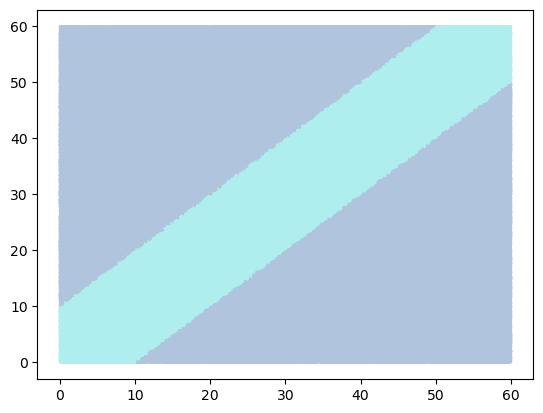

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#Vamos a generar 100,000 simulaciones
muestra=1000000

# Generamos los tiempos aleatorios
# x : tiempo de llegada de Romero [0, 60]
# y : tiempo de llegada de Julieta [0, 60]

x,y = np.random.uniform(0,60, muestra),np.random.uniform(0,60, muestra)

#vamos a añadirnuestra condición de encuentro
# encuentro = np.where(abs(x-y)<=10, 'r', 'b') # r si ser encuentran y b si no se encuentran
encuentro = np.where(abs(x-y)<=10, 'paleturquoise', 'lightsteelblue') # r si ser encuentran y b si no se encuentran

#Calculo de la probabilidad del encuentro
k=0

for elemento in encuentro:
    if elemento == 'r':
        k +=1

print("La probabilidad del evento A es: {}".format(k/muestra))

plt.scatter(x,y,c=encuentro,s=1)
plt.show()

# $\color{crimson}{\text{Pribabilidad Fecuentista}}$

Tenemos la hipótesis de que el espacio muestral es un conjunto finito, y podemos definir la probabilidad asociada a un evento $A$:
$$ f_n(A) = \frac{n(A)}{n}, $$
donde $n(A)$ denota al número de veces que ocurre $A$, y $n$  es el número de veces que se realiza el experimento.

## $\color{lightcoral}{\text{Ejemplo del volado}}$

In [ ]:
import random #Se tiene el lanzamiento de monedas injustas (volados)

#simulamos el lanzamiento de una moneda la probabilidad de que caiga sol es P y águila es el complemnto
def volado(p):
    return 'sol' if random.random() < p else 'aguila'

volado(0.4)

#Sucesión de lanzamientos
a = [volado(0.4) for i in range(10)]
a

a.count('sol')

resultados = [] #lista vacia

for i in range(10):
    resultado = volado(0.4)
    resultados.append(resultado)

resultados # lo imprimimos

# Vamos a simular nuestra probabilidad frecuentista
p = [] # Lista para almacenar las probabilidades

for i in range(1000): #Simula 1000 experimentos
    N = 10 #numero de lanzamientos
    resultados = []
    #Hacemos 10 lanzamientos en cada experimento
    for i in range(N):
        resultado = volado(0.63) #con una probabilidad de .63
        resultados.append(resultado) # que se guarde el resultado en la lista

    num_soles = resultados.count('sol') # cuenta el número de soles
    p_soles  = num_soles / N #calcula la proporción que es número de soles / numero veces se realiza el experimento

    p.append(p_soles)

    #Probabilidad promedio
p_soles_prom = sum(p)/1000
print('Probabilidad: {:.3f}'.format(p_soles_prom))

Probabilidad: 0.640


---

$\color{crimson}{\text{Ejericicio}}$

Se tienen $2$ urnas, cada una de las cuales contiene $10$ bolas numeradas del $1$ al $10$.

Un experimento aleatorio consiste en seleccionar al azar una bola de cada urna.

Sea $X$ la variable aleatoria que representa la diferencia de los números de las dos bolas seleccionadas.

* Define $\Omega$

El espacio muestral $\Omega$ del experimento aleatorio de dos urnas con $10$ bolas cada una, esta compuesto por todas las perejas ordenadas $(i,j)$ tales que $1 \leq i,j \leq 10$


$$\Omega = \{ (i,j) \mid 1 \leq i,j \leq 10 \} $$


y sabemos que $\#\Omega = 10^2 = 100$

* Calcula las probabilidades asociadas
* Define la función de densidad

  $$\
  f_X(x) = P(X = x)\$$
  

* Verifica que $\sum_{x\in R_X}f_X(x) = 1$
* Gráfica la función de densidad

Además, calcula la probabilidad de que los números de las dos bolas seleccionadas difieran por $2$ o más

$$P(X \geq 2) = \sum_{x \geq 2} P(X = x)\$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Definir el espacio muestral
Omega = [(i, j) for i in range(1, 11) for j in range(1, 11)]
num_omega = len(Omega)  # Total de casos posibles (100)
Omega

# Definir la variable aleatoria X = |i - j|
def X(omega):
    return abs(omega[0] - omega[1])

# Calcular la distribución de probabilidad
valores_X = [X(omega) for omega in Omega]
conteo = Counter(valores_X)
n = len(Omega)
densidad = {k: v/n for k, v in conteo.items()}
densidad

{0: 0.1,
 1: 0.18,
 2: 0.16,
 3: 0.14,
 4: 0.12,
 5: 0.1,
 6: 0.08,
 7: 0.06,
 8: 0.04,
 9: 0.02}

In [ ]:
# Mostrar las probabilidades asociadas
df_probabilidades = pd.DataFrame(list(densidad.items()), columns=["Diferencia", "Probabilidad"])
df_probabilidades = df_probabilidades.sort_values("Diferencia")

print("Probabilidades asociadas:")

print(df_probabilidades)

Probabilidades asociadas:
   Diferencia  Probabilidad
0           0          0.10
1           1          0.18
2           2          0.16
3           3          0.14
4           4          0.12
5           5          0.10
6           6          0.08
7           7          0.06
8           8          0.04
9           9          0.02


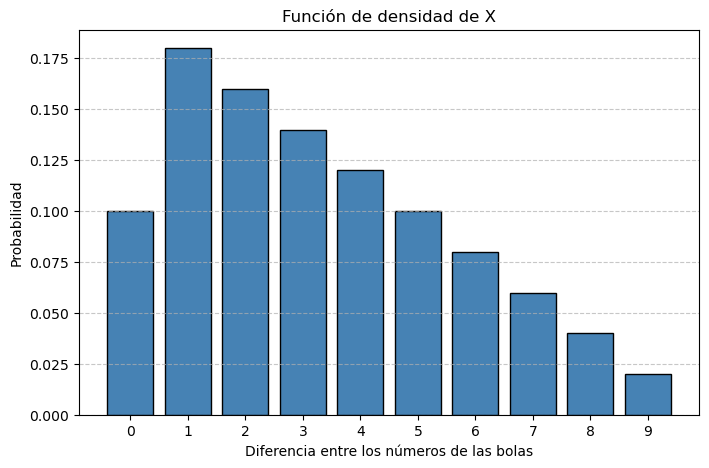

In [ ]:
# Verificar que la suma de probabilidades sea 1
assert np.isclose(sum(densidad.values()), 1), "La suma de probabilidades no es 1"

# Convertir en DataFrame para visualización
df = pd.DataFrame(list(densidad.items()), columns=["Diferencia", "Probabilidad"])
df = df.sort_values("Diferencia")

# Graficar la función de densidad
plt.figure(figsize=(8,5))
plt.bar(df["Diferencia"], df["Probabilidad"], color='steelblue', edgecolor='black')
plt.xlabel("Diferencia entre los números de las bolas")
plt.ylabel("Probabilidad")
plt.title("Función de densidad de X")
plt.xticks(range(10))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Definir el evento Sn (la diferencia sea 2 o más)

Sn = [omega for omega in Omega if X(omega) >= 2]


# Paso 3: Definir la función de probabilidad P(A)
def P(A):
    return len(A) / num_omega

# Calcular la probabilidad de que la diferencia sea 2 o más
prob_dif_2_o_mas = sum([densidad[k] for k in densidad if k >= 2])

print(f"P(X ≥ 2) = {prob_dif_2_o_mas:.4f}")

P(X ≥ 2) = 0.7200
